# Example for consensus
This notebook demonstrates how the multiplicative weights algorithm can enhance the robustness of a consensus algorithm against Byzantine attacks.

## 1. Set some global parameters:

In [356]:
from multiprocessing import Pool
from numpy import float64
from numpy.typing import NDArray

if __name__ == "__main__":
    N_STATE = 3
    N_ITER = 2000
    ALPHA = 0.3

    NORMAL_LB = -100.0  # Lower bound of normal nodes' initial state values
    NORMAL_UB = 100.0  # Upper bound of normal nodes' initial state values

## 2. Define the graph topology and characterize the behavior of Byzantine nodes.
### (1) Define the graph

We consider a network consisting of two categories of nodes with corresponding edges:

```python
NORMAL_NODES = [...]
NORMAL_EDGES = [...]

BYZANTINE_NODES = [...]
BYZANTINE_EDGES = [...]
```

The overall network is formed by the union of the normal and Byzantine nodes and edges:

$$
\mathcal{I} = \mathcal{I}_\text{normal} \cup \mathcal{I}_\text{Byz}, \quad \mathcal{E} = \mathcal{E}_\text{normal} \cup \mathcal{E}_\text{Byz}.
$$

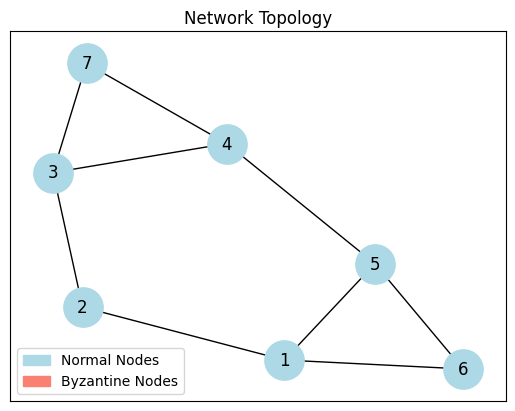

In [357]:
def graph_server(nodes: list[str], edges: list[tuple[str, str]]) -> None:
    from logging import basicConfig, INFO

    basicConfig(level=INFO)

    from topolink import Graph

    graph = Graph(nodes, edges)

    graph.deploy()


if __name__ == "__main__":
    # NORMAL_NODES = ["1", "2", "3", "4", "5", "6"]
    # NORMAL_EDGES = [("1", "2"), ("2", "3"), ("3", "4"), ("4", "5"), ("5", "1"), ("1", "6")]
    # BYZANTINE_NODES = ["7", "8", "9", "10"]
    # BYZANTINE_EDGES = [("2", "7"), ("3", "8"), ("4", "9"), ("5", "10")]

    # A typical network topology that can be used to test overly conservative designs
    NORMAL_NODES = ["1", "2", "3", "4", "5", "6", "7"]
    NORMAL_EDGES = [
        ("1", "2"),
        ("2", "3"),
        ("3", "4"),
        ("4", "5"),
        ("5", "1"),
        ("1", "6"),
        ("5", "6"),
        ("3", "7"),
        ("4", "7"),
    ]
    BYZANTINE_NODES = []
    BYZANTINE_EDGES = []

    NODES = NORMAL_NODES + BYZANTINE_NODES
    EDGES = NORMAL_EDGES + BYZANTINE_EDGES

    N_NORMAL = len(NORMAL_NODES)
    N_BYZANTINE = len(BYZANTINE_NODES)
    N_NODES = N_NORMAL + N_BYZANTINE

    import matplotlib.pyplot as plt
    import networkx as nx

    fig, ax = plt.subplots()
    ax.set_title("Network Topology")

    G = nx.Graph()
    G.add_nodes_from(NODES)
    G.add_edges_from(EDGES)

    pos = nx.spring_layout(G, seed=11, k=0.8)

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=NORMAL_NODES,
        node_color="lightblue",
        node_size=800,
        ax=ax,
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=BYZANTINE_NODES,
        node_color="salmon",
        node_size=800,
        ax=ax,
    )

    nx.draw_networkx_edges(G, pos, ax=ax)
    nx.draw_networkx_labels(G, pos, ax=ax)

    import matplotlib.patches as mpatches

    blue_patch = mpatches.Patch(color="lightblue", label="Normal Nodes")
    red_patch = mpatches.Patch(color="salmon", label="Byzantine Nodes")

    ax.legend(handles=[blue_patch, red_patch], loc="lower left")

### (2) Define the behavior of Byzantine nodes

A Byzantine node ignores the states of its neighbors.
Let the state of node $i$ at iteration $t$ be denoted as $x_i^{(t)}$.
Then the update rule for a Byzantine node can be described as:

1. **Keep state constant:**
$$
x_i^{(t + 1)} = x_i^{(t)}
$$

2. **Update state randomly:**
$$
x_i^{(t)} \sim \mathcal{U}(a, b)
$$
where $\mathcal{U}(a, b)$ denotes a uniform random variable in the range $[a, b]$, which represents the possible values that the Byzantine node can take.

In [358]:
def byzantine_node(
    name: str,
    n_state: int,
    alpha: float,
    n_iter: int,
    type: str,
    lower_bound: float,
    upper_bound: float,
) -> NDArray[float64]:
    from numpy import zeros
    from numpy.random import uniform, seed
    from topolink import NodeHandle

    nh = NodeHandle(name)

    states = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    states[0] = uniform(lower_bound, upper_bound, n_state)

    for k in range(n_iter - 1):
        laplacian = nh.laplacian(states[k])

        if type == "constant":
            states[k + 1] = states[k]
        elif type == "random":
            states[k + 1] = uniform(lower_bound, upper_bound, n_state)
        elif type == "disturbance":
            disturbance = uniform(-10.0, 10.0, n_state)
            states[k + 1] = states[k] - laplacian * alpha + disturbance

    return states


if __name__ == "__main__":
    BYZ_TYPE = "constant"  # Byzantine behavior: "constant", "random", "disturbance"
    BYZ_LB = -100.0
    BYZ_UB = 100.0

## 3. Execute a standard consensus algorithm

In our system, we use the consensus iteration to update the states of nodes. Let the global state vector of all nodes at iteration $k$ be denoted as $X^k \in \mathbb{R}^{nd}$, where $n$ is the number of nodes and $d$ is the dimension of each node's state. The consensus iteration is given by:

$$
X^{(t + 1)} = X^{(t)} - \alpha (L \otimes I_d) X^{(t)},
$$

where:  

- $L \in \mathbb{R}^{n \times n}$ is the **graph Laplacian matrix**, defined as $L = D - A$, with $A$ being the adjacency matrix of the network and $D$ the degree matrix.  
- $I_d \in \mathbb{R}^{d \times d}$ is the **identity matrix**, allowing the Laplacian to act independently on each dimension of the state.  
- $\otimes$ denotes the **Kronecker product**, which expands the Laplacian to operate on the multi-dimensional state vector.  
- $\alpha > 0$ is the **step size** or **learning rate**, controlling how much each node adjusts its state in each iteration.

### (1) Run the algorithm

In [359]:
def baseline_node(
    name: str,
    n_state: int,
    alpha: float,
    n_iter: int,
    lower_bound: float,
    upper_bound: float,
) -> NDArray[float64]:
    from numpy import zeros
    from numpy.random import uniform, seed
    from topolink import NodeHandle

    nh = NodeHandle(name)

    states = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    states[0] = uniform(lower_bound, upper_bound, n_state)

    for k in range(n_iter - 1):
        states[k + 1] = states[k] - nh.laplacian(states[k]) * alpha

    return states


if __name__ == "__main__":
    with Pool(N_NODES + 1) as pool:
        server = pool.apply_async(graph_server, args=(NODES, EDGES))
        baseline_nodes = {
            i: pool.apply_async(
                baseline_node, args=(i, N_STATE, ALPHA, N_ITER, NORMAL_LB, NORMAL_UB)
            )
            for i in NORMAL_NODES
        }
        byzantine_nodes = {
            i: pool.apply_async(
                byzantine_node,
                args=(i, N_STATE, ALPHA, N_ITER, BYZ_TYPE, BYZ_LB, BYZ_UB),
            )
            for i in BYZANTINE_NODES
        }
        baseline_states = {i: node.get() for i, node in baseline_nodes.items()}
        byzantine_states = {i: node.get() for i, node in byzantine_nodes.items()}
        server.get()

INFO:topolink.graph:Graph 'default' running on: 172.26.120.171:34085
INFO:topolink.discovery:Registered graph service with name 'default'
INFO:topolink.graph:Node '4' joined graph 'default' from 172.26.120.171:43411.
INFO:topolink.graph:Node '2' joined graph 'default' from 172.26.120.171:36787.
INFO:topolink.graph:Node '7' joined graph 'default' from 172.26.120.171:40231.
INFO:topolink.graph:Node '6' joined graph 'default' from 172.26.120.171:46205.
INFO:topolink.graph:Node '1' joined graph 'default' from 172.26.120.171:44665.
INFO:topolink.graph:Node '3' joined graph 'default' from 172.26.120.171:38203.
INFO:topolink.graph:Node '5' joined graph 'default' from 172.26.120.171:36329.
INFO:topolink.graph:Graph 'default' registration complete.
INFO:topolink.graph:Sent neighbor information to all nodes in graph 'default'.
INFO:topolink.discovery:Unregistered graph service with name 'default'


### (2) Visualize the Results

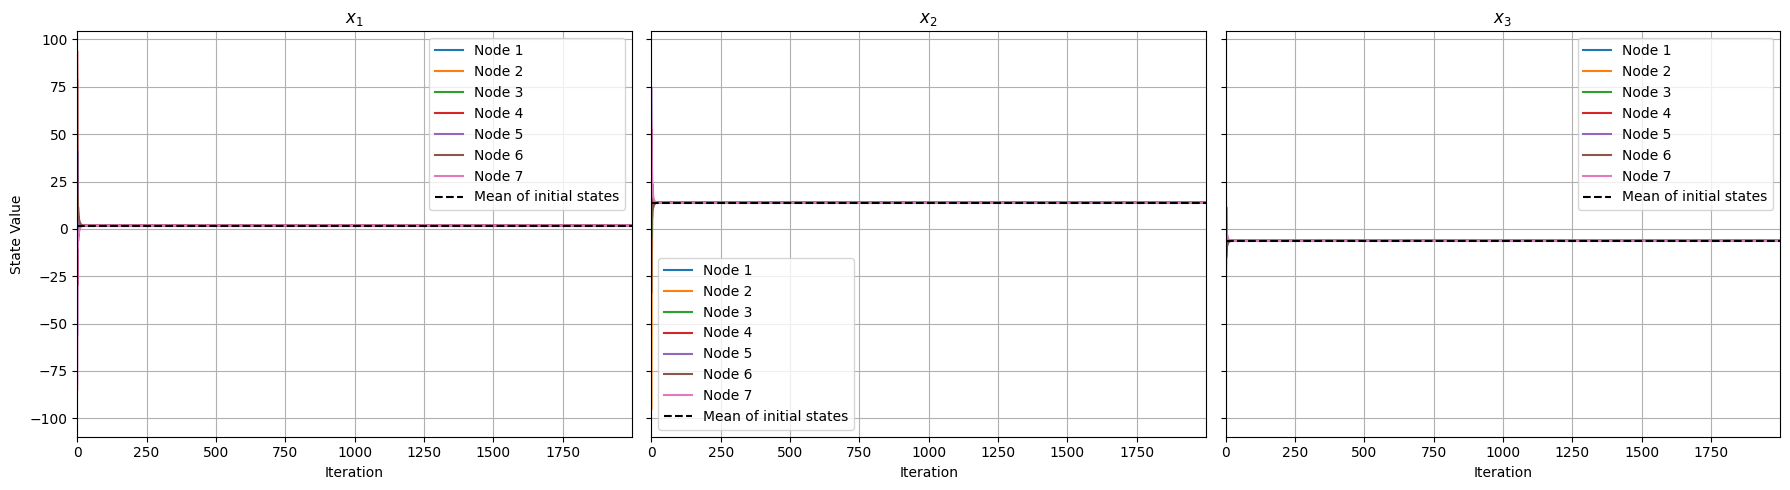

In [360]:
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    from matplotlib.axes import Axes
    from typing import Sequence

    ax1: Sequence[Axes]
    fig1, ax1 = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for i in NORMAL_NODES:
        states = baseline_states[i]
        for j in range(N_STATE):
            (line,) = ax1[j].plot(states[:, j], label=f"Node {i}")

    from numpy import sum as np_sum

    initial_states = [baseline_states[i][0, :] for i in NORMAL_NODES]
    mean_states: NDArray[float64] = np_sum(initial_states, axis=0) / N_NORMAL

    for j in range(N_STATE):
        ax1[j].axhline(
            mean_states[j],
            color="k",
            linestyle="--",
            label="Mean of initial states",
        )

    for j in range(N_STATE):
        ax1[j].set_xlabel("Iteration")
        ax1[j].set_xlim(0, N_ITER - 1)
        ax1[j].legend()
        ax1[j].set_title(f"$x_{j + 1}$")
        ax1[j].grid()

    ax1[0].set_ylabel("State Value")

    fig1.tight_layout()

## 4. Exponential reputation-based consensus algorithm
---

For $n$ experts, each expert $i$ is assigned a weight $\omega_i^{(t)}$ at time step $t$.
At this time step, expert $i$ incurs a loss $l_i^{(t)}$.
The weight of expert $i$ is then updated according to:

### 1. Linear update
$$
\omega_i^{(t + 1)} = \omega_i^{(t)} (1 - \eta l_i^{(t)})
$$
where $\eta$ is a learning rate parameter.

This linear form is simple but may cause negative weights if $\eta l_i^{(t)} > 1$, and is less convenient for theoretical analysis.

### 2. Exponential update (Hedge)
In practice, the exponential update is preferred:
$$
\boxed{\omega_i^{(t + 1)} = \omega_i^{(t)} e^{-\eta l_i^{(t)}}}
$$
where $\eta > 0$ is the learning rate.

For small $\eta$, note that:
$$
e^{-\eta l_i^{(t)}} \approx 1 - \epsilon l_i^{(t)}
$$
so the linear rule can be viewed as a first-order approximation of the exponential update.

Moreover, it is often more convenient to express the update in terms of the **cumulative loss**:
$$
L_i^{(t)} = \sum_{\tau = 0}^{t} l_i^{(\tau)}.
$$
Substituting this into the recursive rule gives the equivalent closed-form expression:
$$
\boxed{\omega_i^{(t)} = \exp(-\eta L_i^{(t)})}.
$$
This form is frequently used in practice because it avoids repeated multiplication and makes explicit how the weight of each expert decays exponentially with its cumulative loss.

> **Note**
> The following notation is independent of the above; the above was written according to the original paper.

---

### 1. Pairwise dispersion loss
For each node $i$ and each neighbor $j \in \mathcal{N}_i$, we define the **cumulative loss** as

$$
L_{ij}^{(t)} = \sum_{v \in \mathcal{N}_i} \frac{\| x_j^{(t)} - x_v^{(t)} \|}{d_i},
$$

where $x_j^{(t)}$ denotes the state received from neighbor $j$ at iteration $t$, $\mathcal{N}_i$ is the set of neighbors of node $i$, and $d_i = |\mathcal{N}_i|$ denotes its degree.
This definition quantifies the local inconsistency between neighbor $j$ and the remaining neighbors of node $i$ at iteration $t$.

### 2. Median deviation loss
Alternatively, we can define a **median-based cumulative loss**, which measures the deviation of each neighbor's state from the element-wise median state among all neighbors:

$$
L_{ij}^{(t)} = \| x_j^{(t)} - x_{\text{med}}^{(t)} \|.
$$

where $x_{\text{med}}^{(t)} = \operatorname{median}\big(\{ x_v^{(t)} : v \in \mathcal{N}_i \}\big)$.

---

At each iteration, node $i$ first obtains an **estimate** $\hat{x}_i^{(t)}$ of its consensus value based on the states of its neighbors.
The estimate is computed as a weighted average of the neighbors’ states:
$$
\hat{x}_{i}^{(t)} = \frac{\sum_{j \in \mathcal{N}_i} \omega_j^{(t)} x_j^{(t)}}{\sum_{j \in \mathcal{N}_i} \omega_j^{(t)}}.
$$

Subsequently, node $i$ **updates its local state** according to
$$
x_i^{(t + 1)} = (1 - \alpha) x_i^{(t)} + \alpha \hat{x}_i^{(t)},
$$
where $\alpha \in [0, 1]$ is a weighting factor that balances the influence of the new estimate and the previous state.

---

### (1) Run the algorithm

In [376]:
def mw_node(
    name: str,
    n_state: int,
    alpha: float,
    n_iter: int,
    lower_bound: float,
    upper_bound: float,
) -> tuple[NDArray[float64], dict[str, NDArray[float64]]]:
    from numpy import zeros
    from numpy.random import uniform, seed
    from topolink import NodeHandle

    nh = NodeHandle(name)

    from xrepc import XRepC

    xrepc = XRepC(nh.neighbor_names, alpha=alpha, eta=1.0)

    states = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    states[0] = uniform(lower_bound, upper_bound, n_state)

    probs = {neighbor: zeros(n_iter - 1) for neighbor in nh.neighbor_names}

    for k in range(n_iter - 1):
        # Broadcast current state (make decision) and gather neighbors' states (observe results)
        nh.broadcast(states[k])
        state_js = nh.gather()

        # Compute new state
        states[k + 1] = xrepc.aggregate(states[k], state_js)

        if name == "3" and 1500 <= k <= 1510:
            states[k + 1] += uniform(-10.0, 10.0, n_state)

        # Record normalized weights history
        for neighbor in nh.neighbor_names:
            p = xrepc.probs
            probs[neighbor][k] = p[neighbor]

    return states, probs


if __name__ == "__main__":
    with Pool(N_NODES + 1) as pool:
        server = pool.apply_async(graph_server, args=(NODES, EDGES))
        mw_nodes = {
            i: pool.apply_async(
                mw_node, args=(i, N_STATE, ALPHA, N_ITER, NORMAL_LB, NORMAL_UB)
            )
            for i in NORMAL_NODES
        }
        byzantine_nodes = {
            i: pool.apply_async(
                byzantine_node,
                args=(i, N_STATE, ALPHA, N_ITER, BYZ_TYPE, BYZ_LB, BYZ_UB),
            )
            for i in BYZANTINE_NODES
        }
        xrepc_results = {i: node.get() for i, node in mw_nodes.items()}
        byzantine_states = {i: node.get() for i, node in byzantine_nodes.items()}
        server.get()

INFO:topolink.graph:Graph 'default' running on: 172.26.120.171:44777
INFO:topolink.discovery:Registered graph service with name 'default'
INFO:topolink.graph:Node '4' joined graph 'default' from 172.26.120.171:33605.
INFO:topolink.graph:Node '5' joined graph 'default' from 172.26.120.171:45893.
INFO:topolink.graph:Node '7' joined graph 'default' from 172.26.120.171:41519.
INFO:topolink.graph:Node '1' joined graph 'default' from 172.26.120.171:34279.
INFO:topolink.graph:Node '6' joined graph 'default' from 172.26.120.171:39867.
INFO:topolink.graph:Node '2' joined graph 'default' from 172.26.120.171:38153.
INFO:topolink.graph:Node '3' joined graph 'default' from 172.26.120.171:44923.
INFO:topolink.graph:Graph 'default' registration complete.
INFO:topolink.graph:Sent neighbor information to all nodes in graph 'default'.
INFO:topolink.discovery:Unregistered graph service with name 'default'


### (2) Visualize the Results

#### 1. State evolution for each normal node

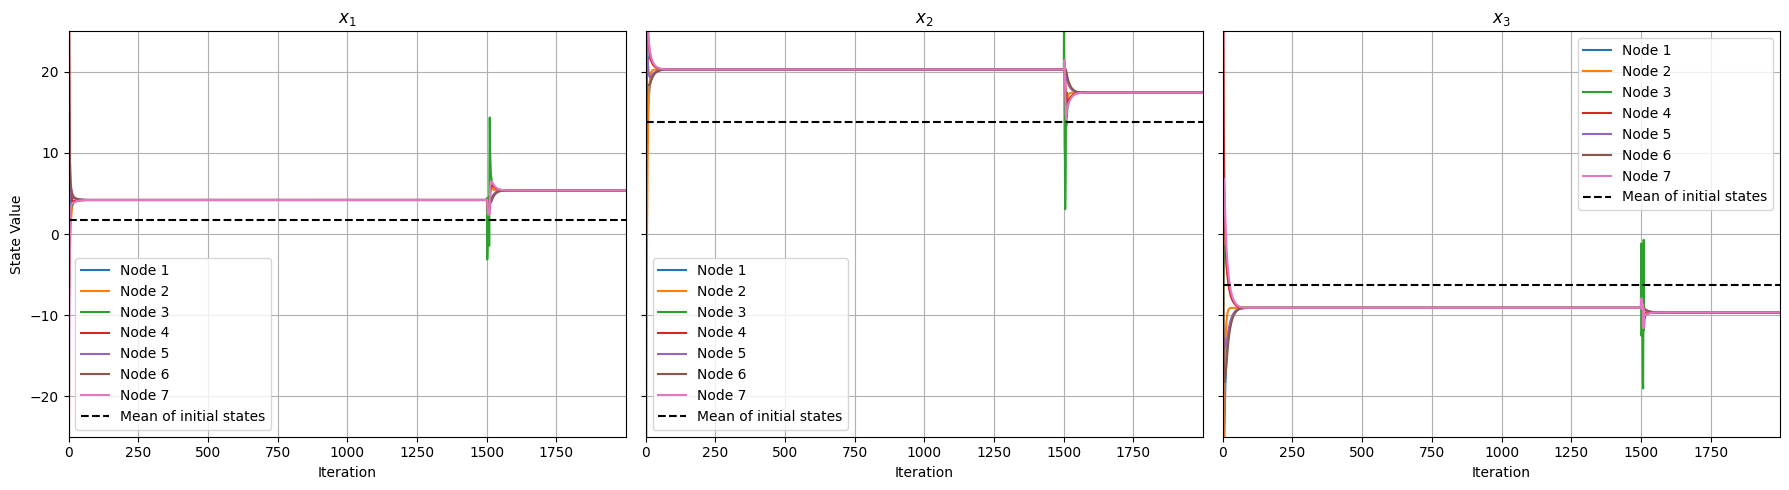

In [377]:
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    from matplotlib.axes import Axes
    from typing import Sequence

    ax2: Sequence[Axes]
    fig2, ax2 = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    xrepc_states = {i: xrepc_results[i][0] for i in NORMAL_NODES}

    for i in NORMAL_NODES:
        states = xrepc_states[i]
        for j in range(N_STATE):
            (line,) = ax2[j].plot(states[:, j], label=f"Node {i}")

    from numpy import sum as np_sum

    initial_states = [xrepc_states[i][0, :] for i in NORMAL_NODES]
    mean_states: NDArray[float64] = np_sum(initial_states, axis=0) / N_NORMAL

    for j in range(N_STATE):
        ax2[j].axhline(
            mean_states[j], color="k", linestyle="--", label="Mean of initial states"
        )

    for j in range(N_STATE):
        ax2[j].set_xlabel("Iteration")
        ax2[j].set_xlim(0, N_ITER - 1)
        ax2[j].set_ylim(-25, 25)
        ax2[j].legend()
        ax2[j].set_title(f"$x_{j + 1}$")
        ax2[j].grid()

    ax2[0].set_ylabel("State Value")

    fig2.tight_layout()

#### 2. Weight evolution for each node

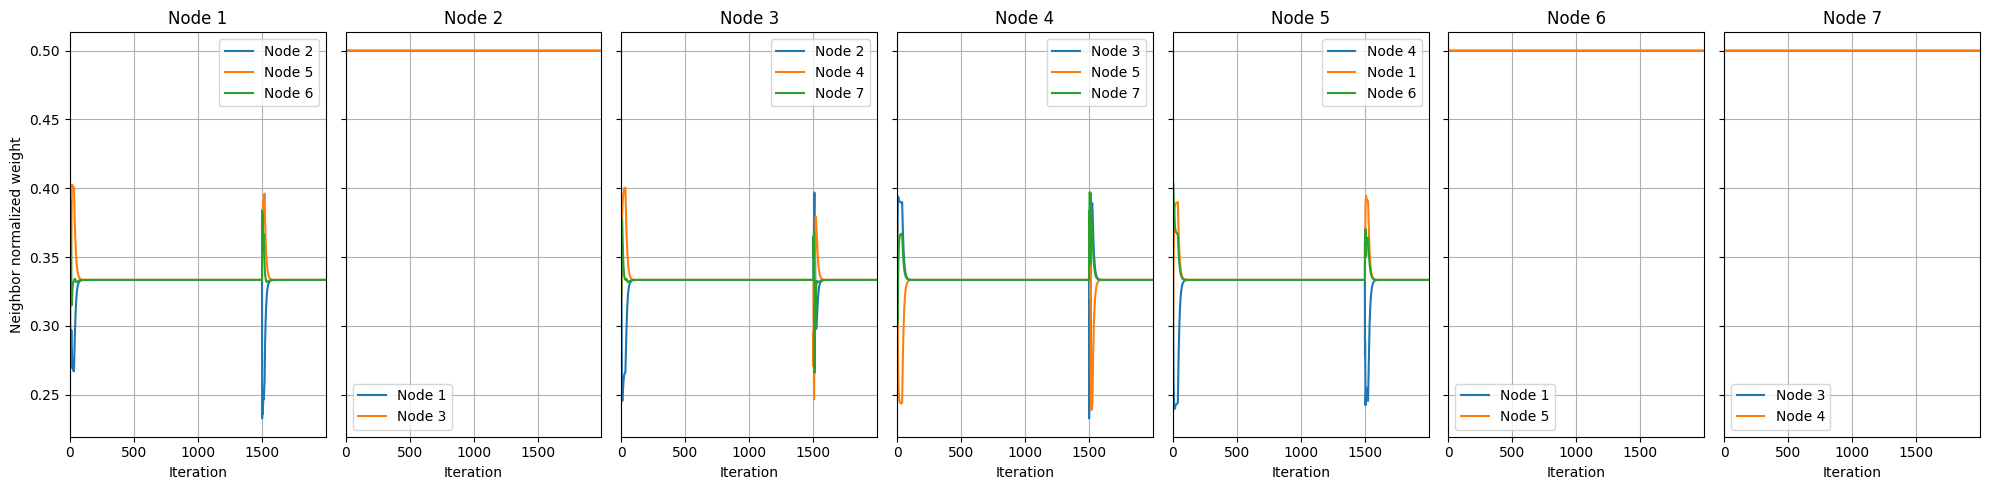

In [378]:
if __name__ == "__main__":
    ax3: Sequence[Axes]
    fig3, ax3 = plt.subplots(1, N_NORMAL, figsize=(20, 5), sharey=True)

    xrepc_probs = {i: xrepc_results[i][1] for i in NORMAL_NODES}

    for i, ax in zip(NORMAL_NODES, ax3):
        probs_for_i = xrepc_probs[i]
        for j in probs_for_i:
            (line,) = ax.plot(probs_for_i[j], label=f"Node {j}")
        ax.set_title(f"Node {i}")
        ax.set_xlabel("Iteration")
        ax.set_xlim(0, N_ITER - 1)
        ax.legend()
        ax.grid()

    ax3[0].set_ylabel("Neighbor normalized weight")

    fig3.tight_layout()

## 5. Reputation-based consensus

---

### (1) Run the algorithm

In [371]:
def repc_node(
    name: str,
    n_state: int,
    alpha: float,
    n_iter: int,
    lower_bound: float,
    upper_bound: float,
) -> tuple[NDArray[float64], dict[str, NDArray[float64]]]:
    from topolink import NodeHandle

    nh = NodeHandle(name)

    from xrepc.baselines import RepC

    repc = RepC(nh.neighbor_names, alpha=alpha, eps=0.99)

    from numpy import zeros
    from numpy.random import uniform, seed

    states = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    states[0] = uniform(lower_bound, upper_bound, n_state)

    probs = {neighbor: zeros(n_iter - 1) for neighbor in nh.neighbor_names}

    for k in range(n_iter - 1):
        # Update state
        nh.broadcast(states[k])
        state_js = nh.gather()

        # Compute new state
        states[k + 1] = repc.aggregate(states[k], state_js)

        if name == "3" and 1500 <= k <= 1510:
            states[k + 1] += uniform(-10.0, 10.0, n_state)

        # Record normalized weights history
        for neighbor in nh.neighbor_names:
            p = repc.probs
            probs[neighbor][k] = p[neighbor]

    return states, probs


if __name__ == "__main__":
    with Pool(N_NODES + 1) as pool:
        server = pool.apply_async(graph_server, args=(NODES, EDGES))
        repc_nodes = {
            i: pool.apply_async(
                repc_node, args=(i, N_STATE, ALPHA, N_ITER, NORMAL_LB, NORMAL_UB)
            )
            for i in NORMAL_NODES
        }
        byzantine_nodes = {
            i: pool.apply_async(
                byzantine_node,
                args=(i, N_STATE, ALPHA, N_ITER, BYZ_TYPE, BYZ_LB, BYZ_UB),
            )
            for i in BYZANTINE_NODES
        }
        repc_results = {i: node.get() for i, node in repc_nodes.items()}
        byzantine_states = {i: node.get() for i, node in byzantine_nodes.items()}
        server.get()

INFO:topolink.graph:Graph 'default' running on: 172.26.120.171:44129
INFO:topolink.discovery:Registered graph service with name 'default'
INFO:topolink.graph:Node '7' joined graph 'default' from 172.26.120.171:39179.
INFO:topolink.graph:Node '4' joined graph 'default' from 172.26.120.171:42101.
INFO:topolink.graph:Node '6' joined graph 'default' from 172.26.120.171:38997.
INFO:topolink.graph:Node '5' joined graph 'default' from 172.26.120.171:39139.
INFO:topolink.graph:Node '2' joined graph 'default' from 172.26.120.171:34081.
INFO:topolink.graph:Node '1' joined graph 'default' from 172.26.120.171:44527.
INFO:topolink.graph:Node '3' joined graph 'default' from 172.26.120.171:44147.
INFO:topolink.graph:Graph 'default' registration complete.
INFO:topolink.graph:Sent neighbor information to all nodes in graph 'default'.
INFO:topolink.discovery:Unregistered graph service with name 'default'


### (2) Visualize the Results

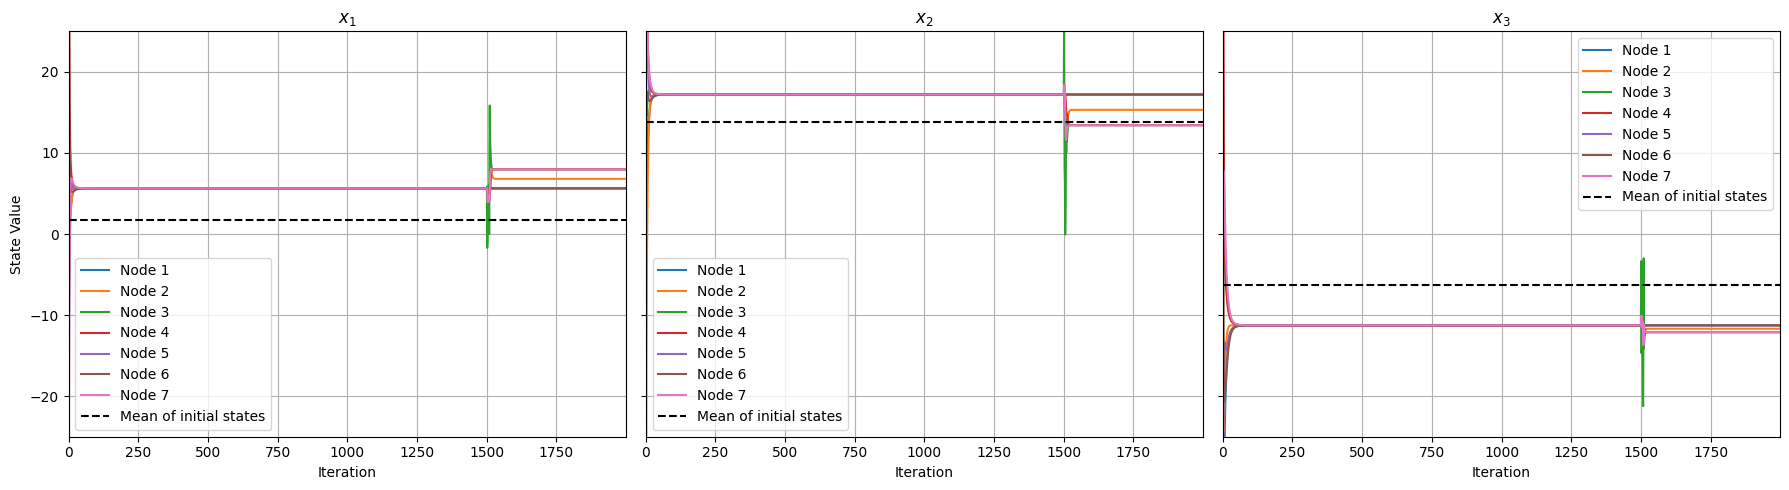

In [375]:
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    from matplotlib.axes import Axes
    from typing import Sequence

    ax4: Sequence[Axes]
    fig4, ax4 = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    repc_states = {i: repc_results[i][0] for i in NORMAL_NODES}

    for i in NORMAL_NODES:
        states = repc_states[i]
        for j in range(N_STATE):
            (line,) = ax4[j].plot(states[:, j], label=f"Node {i}")

    from numpy import sum as np_sum

    initial_states = [repc_states[i][0, :] for i in NORMAL_NODES]
    mean_states: NDArray[float64] = np_sum(initial_states, axis=0) / N_NORMAL

    for j in range(N_STATE):
        ax4[j].axhline(
            mean_states[j], color="k", linestyle="--", label="Mean of initial states"
        )

    for j in range(N_STATE):
        ax4[j].set_xlabel("Iteration")
        ax4[j].set_xlim(0, N_ITER - 1)
        ax4[j].set_ylim(-25, 25)
        ax4[j].legend()
        ax4[j].set_title(f"$x_{j + 1}$")
        ax4[j].grid()

    ax4[0].set_ylabel("State Value")

    fig4.tight_layout()

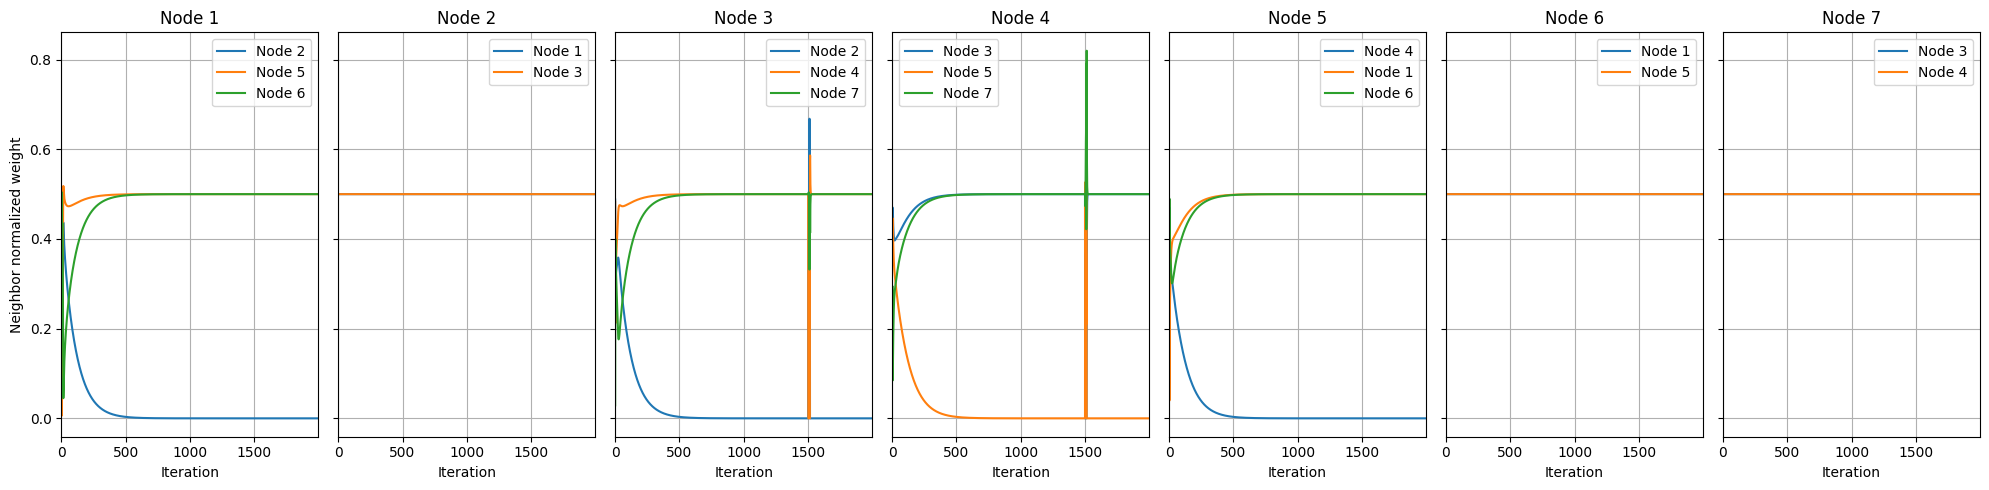

In [379]:
if __name__ == "__main__":
    ax5: Sequence[Axes]
    fig5, ax5 = plt.subplots(1, N_NORMAL, figsize=(20, 5), sharey=True)

    repc_probs = {i: repc_results[i][1] for i in NORMAL_NODES}

    for i, ax in zip(NORMAL_NODES, ax5):
        probs_for_i = repc_probs[i]
        for j in probs_for_i:
            (line,) = ax.plot(probs_for_i[j], label=f"Node {j}")
        ax.set_title(f"Node {i}")
        ax.set_xlabel("Iteration")
        ax.set_xlim(0, N_ITER - 1)
        ax.legend()
        ax.grid()

    ax5[0].set_ylabel("Neighbor normalized weight")

    fig5.tight_layout()

## 6. Byzantine attack type

/tmp/ipykernel_38864/1636822366.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax5[j].legend()


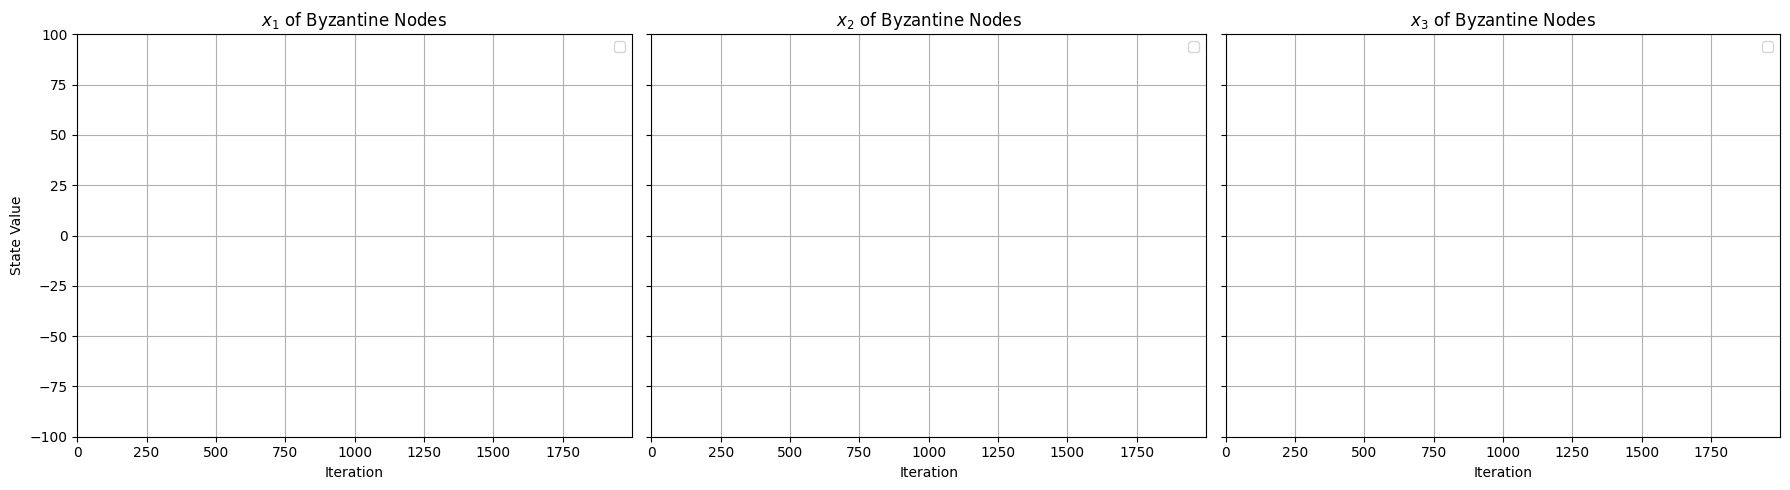

In [367]:
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    from matplotlib.axes import Axes
    from typing import Sequence

    ax5: Sequence[Axes]
    fig5, ax5 = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for i in BYZANTINE_NODES:
        states = byzantine_states[i]
        for j in range(N_STATE):
            (line,) = ax5[j].plot(states[:, j])
            line.set_label(f"Node {i}")

    ax5[0].set_ylabel("State Value")
    ax5[0].set_ylim(BYZ_LB, BYZ_UB)
    for j in range(N_STATE):
        ax5[j].set_xlabel("Iteration")
        ax5[j].set_xlim(0, N_ITER - 1)
        ax5[j].legend()
        ax5[j].set_title(f"$x_{j + 1}$ of Byzantine Nodes")
        ax5[j].grid()

    fig5.tight_layout()